# EV Charging Demand Forecasting for Palo Alto

## Business Problem

EV charging operators need to understand demand patterns and forecast future usage to optimize charger availability, reduce wait times, and improve infrastructure planning.

## Data Loading & Initial Inspection

Load the dataset and review its structure, dimensions, and available variables.

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/EVChargingStationUsage.csv")

df.head()

/tmp/ipykernel_12644/2849252121.py:5: DtypeWarning: Columns (0: User ID, 1: County, 2: Model Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/EVChargingStationUsage.csv")


,Station Name,MAC Address,Org Name,Start Date,Start Time Zone,End Date,End Time Zone,Transaction Date (Pacific Time),Total Duration (hh:mm:ss),Charging Time (hh:mm:ss),...,Longitude,Currency,Fee,Ended By,Plug In Event Id,Driver Postal Code,User ID,County,System S/N,Model Number
0,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/29/2011 20:17,PDT,7/29/2011 23:20,PDT,7/29/2011 23:20,3:03:32,1:54:03,...,-122.160309,USD,0.0,Plug Out at Vehicle,3,95124.0,3284.0,NaN,NaN,NaN
1,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 0:00,PDT,7/30/2011 0:02,PDT,7/30/2011 0:02,0:02:06,0:01:54,...,-122.160309,USD,0.0,Customer,4,94301.0,4169.0,NaN,NaN,NaN
2,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 8:16,PDT,7/30/2011 12:34,PDT,7/30/2011 12:34,4:17:32,4:17:28,...,-122.160309,USD,0.0,Plug Out at Vehicle,5,94301.0,4169.0,NaN,NaN,NaN
3,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 14:51,PDT,7/30/2011 16:55,PDT,7/30/2011 16:55,2:03:24,2:02:58,...,-122.160309,USD,0.0,Customer,6,94302.0,2545.0,NaN,NaN,NaN
4,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 18:51,PDT,7/30/2011 20:03,PDT,7/30/2011 20:03,1:11:24,0:43:54,...,-122.160309,USD,0.0,Plug Out at Vehicle,7,94043.0,3765.0,NaN,NaN,NaN


In [68]:
df.shape

(259415, 33)

In [69]:
df.columns

Index(['Station Name', 'MAC Address', 'Org Name', 'Start Date',
       'Start Time Zone', 'End Date', 'End Time Zone',
       'Transaction Date (Pacific Time)', 'Total Duration (hh:mm:ss)',
       'Charging Time (hh:mm:ss)', 'Energy (kWh)', 'GHG Savings (kg)',
       'Gasoline Savings (gallons)', 'Port Type', 'Port Number', 'Plug Type',
       'EVSE ID', 'Address 1', 'City', 'State/Province', 'Postal Code',
       'Country', 'Latitude', 'Longitude', 'Currency', 'Fee', 'Ended By',
       'Plug In Event Id', 'Driver Postal Code', 'User ID', 'County',
       'System S/N', 'Model Number'],
      dtype='str')

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 259415 entries, 0 to 259414
Data columns (total 33 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Station Name                     259415 non-null  str    
 1   MAC Address                      259415 non-null  str    
 2   Org Name                         259415 non-null  str    
 3   Start Date                       259415 non-null  str    
 4   Start Time Zone                  259415 non-null  str    
 5   End Date                         259415 non-null  str    
 6   End Time Zone                    259415 non-null  str    
 7   Transaction Date (Pacific Time)  259206 non-null  str    
 8   Total Duration (hh:mm:ss)        259415 non-null  str    
 9   Charging Time (hh:mm:ss)         259415 non-null  str    
 10  Energy (kWh)                     259415 non-null  float64
 11  GHG Savings (kg)                 259415 non-null  float64
 12  Gasoline Savi

## Data Quality Assessment

Evaluate missing values, date consistency, and data completeness before analysis.

In [71]:
df.isnull().sum().sort_values(ascending=False).head(15)

County                             84665
System S/N                         78948
EVSE ID                            78948
Model Number                       78948
Driver Postal Code                  8402
User ID                             7677
Currency                            1788
Ended By                             248
Transaction Date (Pacific Time)      209
Port Type                              9
Station Name                           0
Total Duration (hh:mm:ss)              0
MAC Address                            0
Start Time Zone                        0
End Date                               0
dtype: int64

## Data Cleaning

Converted timestamp columns into datetime format and removed incomplete records with missing dates.

In [72]:
df[['Start Date','End Date']].head()

,Start Date,End Date
0,7/29/2011 20:17,7/29/2011 23:20
1,7/30/2011 0:00,7/30/2011 0:02
2,7/30/2011 8:16,7/30/2011 12:34
3,7/30/2011 14:51,7/30/2011 16:55
4,7/30/2011 18:51,7/30/2011 20:03


In [73]:
df['City'].value_counts().head(10)

City
Palo Alto    259415
Name: count, dtype: int64

In [74]:
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['End Date'] = pd.to_datetime(df['End Date'], errors='coerce')

In [75]:
df[['Start Date','End Date']].isnull().sum()

Start Date     0
End Date      40
dtype: int64

In [76]:
df = df.dropna(subset=['Start Date', 'End Date'])

## Feature Engineering

Created time-based variables to analyze charging demand patterns by hour, weekday, month, and year.

In [77]:
df['date'] = df['Start Date'].dt.date
df['hour'] = df['Start Date'].dt.hour
df['weekday'] = df['Start Date'].dt.day_name()
df['month'] = df['Start Date'].dt.month
df['year'] = df['Start Date'].dt.year

In [78]:
df[['date','hour','weekday','month','year']].head()

,date,hour,weekday,month,year
0,2011-07-29,20,Friday,7,2011
1,2011-07-30,0,Saturday,7,2011
2,2011-07-30,8,Saturday,7,2011
3,2011-07-30,14,Saturday,7,2011
4,2011-07-30,18,Saturday,7,2011


In [79]:
df = df.dropna(subset=['Start Date', 'End Date'])

In [80]:
df['date'] = df['Start Date'].dt.date
df['hour'] = df['Start Date'].dt.hour
df['weekday'] = df['Start Date'].dt.day_name()
df['month'] = df['Start Date'].dt.month
df['year'] = df['Start Date'].dt.year

In [81]:
df[['date','hour','weekday','month','year']].head()

,date,hour,weekday,month,year
0,2011-07-29,20,Friday,7,2011
1,2011-07-30,0,Saturday,7,2011
2,2011-07-30,8,Saturday,7,2011
3,2011-07-30,14,Saturday,7,2011
4,2011-07-30,18,Saturday,7,2011


## Exploratory Data Analysis

Analyze charging behavior across hours, weekdays, and historical trends to understand network demand patterns.

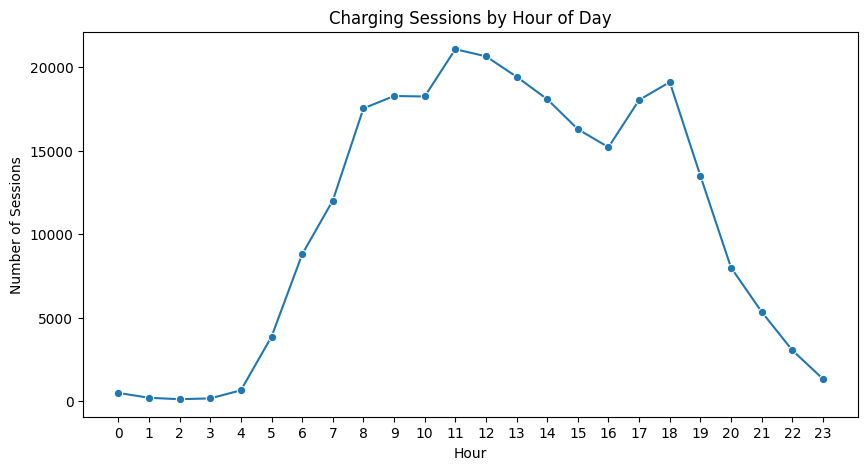

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

hourly_sessions = df.groupby('hour').size().reset_index(name='sessions')

plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_sessions, x='hour', y='sessions', marker='o')
plt.title("Charging Sessions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Sessions")
plt.xticks(range(0,24))
plt.show()

### Insight

This chart highlights the busiest charging hours, helping operators identify peak demand windows and optimize charger availability.

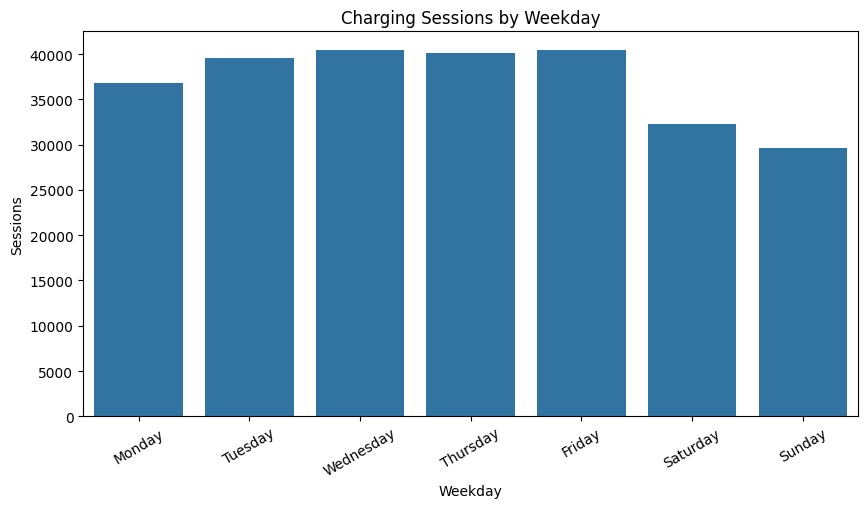

In [83]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

weekday_sessions = df['weekday'].value_counts().reindex(weekday_order)

plt.figure(figsize=(10,5))
sns.barplot(x=weekday_sessions.index, y=weekday_sessions.values)
plt.title("Charging Sessions by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Sessions")
plt.xticks(rotation=30)
plt.show()

### Insight

Comparing weekdays and weekends helps reveal commuter behavior and business-related charging demand.

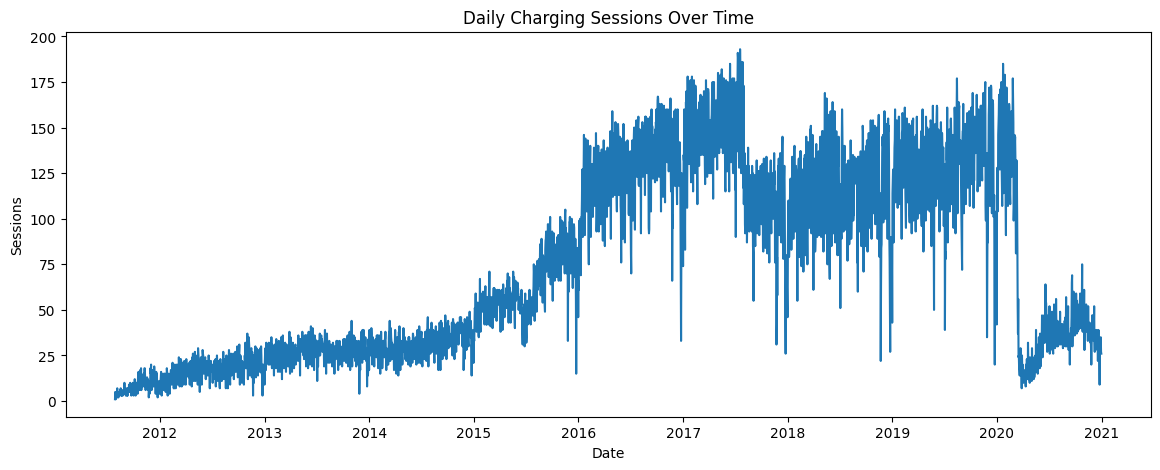

In [84]:
daily_sessions = df.groupby('date').size().reset_index(name='sessions')

plt.figure(figsize=(14,5))
sns.lineplot(data=daily_sessions, x='date', y='sessions')
plt.title("Daily Charging Sessions Over Time")
plt.xlabel("Date")
plt.ylabel("Sessions")
plt.show()

### Insight

Historical demand trends provide the foundation for forecasting future charging needs and infrastructure planning.

### Insight

Historical demand trends provide the foundation for forecasting future charging needs and infrastructure planning.

In [85]:
daily_sessions = df.groupby('date').size().reset_index(name='sessions')

daily_sessions['date'] = pd.to_datetime(daily_sessions['date'])

daily_sessions.head()

,date,sessions
0,2011-07-29,1
1,2011-07-30,5
2,2011-07-31,3
3,2011-08-01,1
4,2011-08-02,3


In [86]:
daily_sessions['dayofweek'] = daily_sessions['date'].dt.dayofweek
daily_sessions['month'] = daily_sessions['date'].dt.month
daily_sessions['day'] = daily_sessions['date'].dt.day
daily_sessions['year'] = daily_sessions['date'].dt.year

In [87]:
from sklearn.model_selection import train_test_split

X = daily_sessions[['dayofweek','month','day','year']]
y = daily_sessions['sessions']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [88]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [89]:
predictions = model.predict(X_test)

In [90]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", round(mae,2))
print("R2 Score:", round(r2,2))

MAE: 47.51
R2 Score: -0.44


## Model Improvement

The baseline model showed limited predictive performance. A second iteration was developed using lag features and rolling demand trends to better capture temporal behavior.

In [91]:
daily_sessions = daily_sessions.sort_values('date')

In [92]:
daily_sessions['lag_1'] = daily_sessions['sessions'].shift(1)
daily_sessions['lag_7'] = daily_sessions['sessions'].shift(7)
daily_sessions['rolling_7'] = daily_sessions['sessions'].rolling(7).mean()

daily_sessions = daily_sessions.dropna()

In [93]:
X = daily_sessions[
    ['dayofweek','month','day','year','lag_1','lag_7','rolling_7']
]

y = daily_sessions['sessions']

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [95]:
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [96]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Improved MAE:", round(mae,2))
print("Improved R2:", round(r2,2))

Improved MAE: 9.88
Improved R2: 0.93


## Forecast Performance

Compare actual charging demand against predicted sessions to evaluate model accuracy.

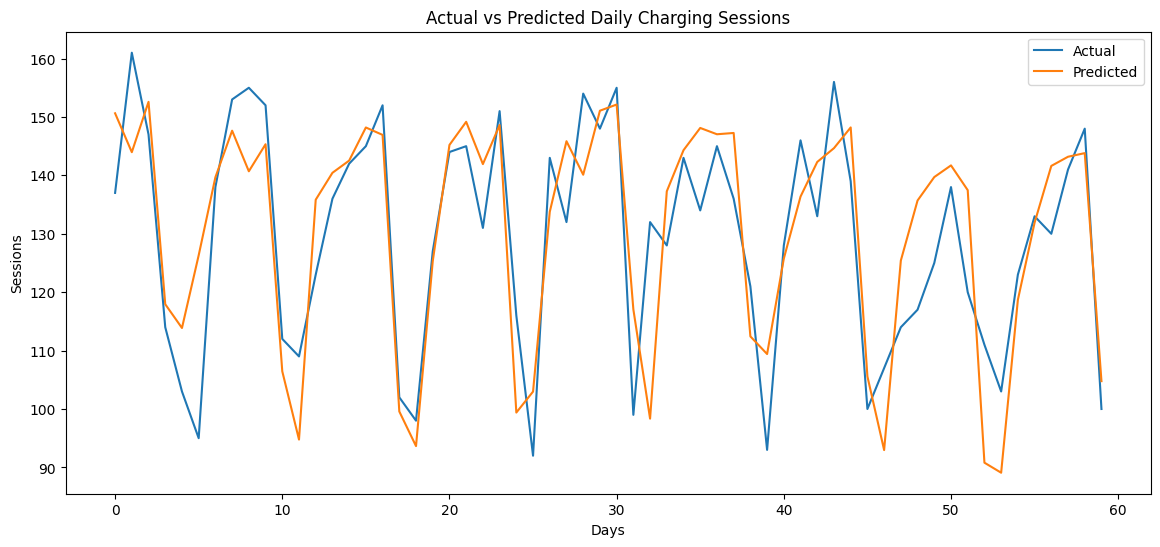

In [97]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
}).reset_index(drop=True)

plt.figure(figsize=(14,6))
plt.plot(results['Actual'].values[:60], label='Actual')
plt.plot(results['Predicted'].values[:60], label='Predicted')
plt.title("Actual vs Predicted Daily Charging Sessions")
plt.xlabel("Days")
plt.ylabel("Sessions")
plt.legend()
plt.show()

### Insight

The improved model closely follows historical charging demand patterns, demonstrating strong forecasting capability for operational planning.

## Business Recommendations

Based on historical demand patterns and forecasting results, the following actions are recommended for EV charging network operators:

- Increase charger availability during peak demand hours.
- Use forecasts to optimize maintenance schedules during low-usage periods.
- Expand infrastructure in consistently high-demand locations.
- Improve operational planning using demand prediction models.

## Final Conclusion

This project demonstrates how historical EV charging session data can be transformed into actionable operational insights through data analytics and machine learning forecasting.

By combining SQL-style analysis, exploratory data analysis, and predictive modeling, organizations can better manage charger utilization and support future EV infrastructure growth.